In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Ready! Train:", X_train.shape, "Test:", X_test.shape)

Ready! Train: (16512, 8) Test: (4128, 8)


In [4]:
# Train Decision Tree WITHOUT any depth limit
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

# Predict on BOTH train and test
train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

# Calculate RMSE for both
mse_1=mean_squared_error(y_train, train_pred)
mse_2=mean_squared_error(y_test, test_pred)
train_rmse = mse_1**0.5
test_rmse = mse_2 **0.5

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
print(f"Gap       : {(test_rmse - train_rmse):.4f}")

Train RMSE: 0.0000
Test  RMSE: 0.7030
Gap       : 0.7030


In [5]:
# Cross-validation gives more reliable score
# Splits data into 5 parts, tests 5 times
cv_scores = cross_val_score(
    tree, X_scaled, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv_rmse = -cv_scores.mean()
print(f"Cross-Validation RMSE: {cv_rmse:.4f}")

Cross-Validation RMSE: 0.8957


In [6]:
# Automatically find best settings
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)

grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 10}


In [9]:
# Get the best model from GridSearchCV
best_tree = grid.best_estimator_

# Predict on test data
y_pred = best_tree.predict(X_test)

# Calculate metrics
mse_3=mean_squared_error(y_test, y_pred)
rmse=mse_3**0.5
r2 = r2_score(y_test, y_pred)

print(f"Optimized Decision Tree RMSE: {rmse:.4f}")
print(f"Optimized Decision Tree R²  : {r2:.4f}")

Optimized Decision Tree RMSE: 0.6454
Optimized Decision Tree R²  : 0.6821


In [11]:
# Train baseline models for comparison
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
mse_4=mean_squared_error(y_test, lr_pred)
lr_rmse = mse_4**0.5
lr_r2 = r2_score(y_test, lr_pred)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
mse_5=mean_squared_error(y_test, ridge_pred)
ridge_rmse = mse_5**0.5
ridge_r2 = r2_score(y_test, ridge_pred)

# Summary table
results = {
    "Model": ["Linear Regression", "Ridge Regression", "Tuned Decision Tree"],
    "RMSE": [round(lr_rmse,4), round(ridge_rmse,4), round(rmse,4)],
    "R2 Score": [round(lr_r2,4), round(ridge_r2,4), round(r2,4)]
}

results_df = pd.DataFrame(results)
print(results_df)

                 Model    RMSE  R2 Score
0    Linear Regression  0.7456    0.5758
1     Ridge Regression  0.7456    0.5758
2  Tuned Decision Tree  0.6454    0.6821


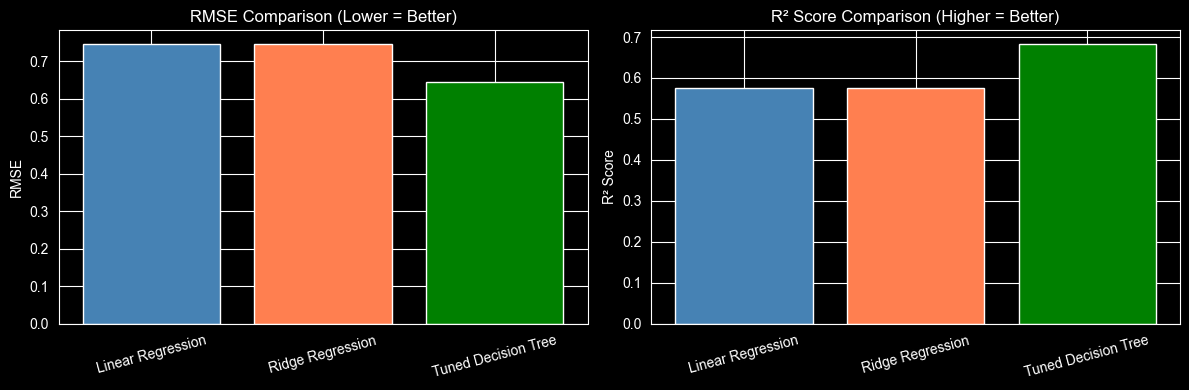

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# RMSE Comparison
axes[0].bar(results_df["Model"], results_df["RMSE"],
            color=["steelblue", "coral", "green"])
axes[0].set_title("RMSE Comparison (Lower = Better)")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis='x', rotation=15)

# R2 Comparison
axes[1].bar(results_df["Model"], results_df["R2 Score"],
            color=["steelblue", "coral", "green"])
axes[1].set_title("R² Score Comparison (Higher = Better)")
axes[1].set_ylabel("R² Score")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()